# Visualizations

Visualization is the process of representing data in a graphical form so that it becomes easier to understand, identify patterns, compare values, and draw conclusions.

Instead of looking at thousands of rows in a table, you use charts and graphs to quickly understand what the data is telling you.

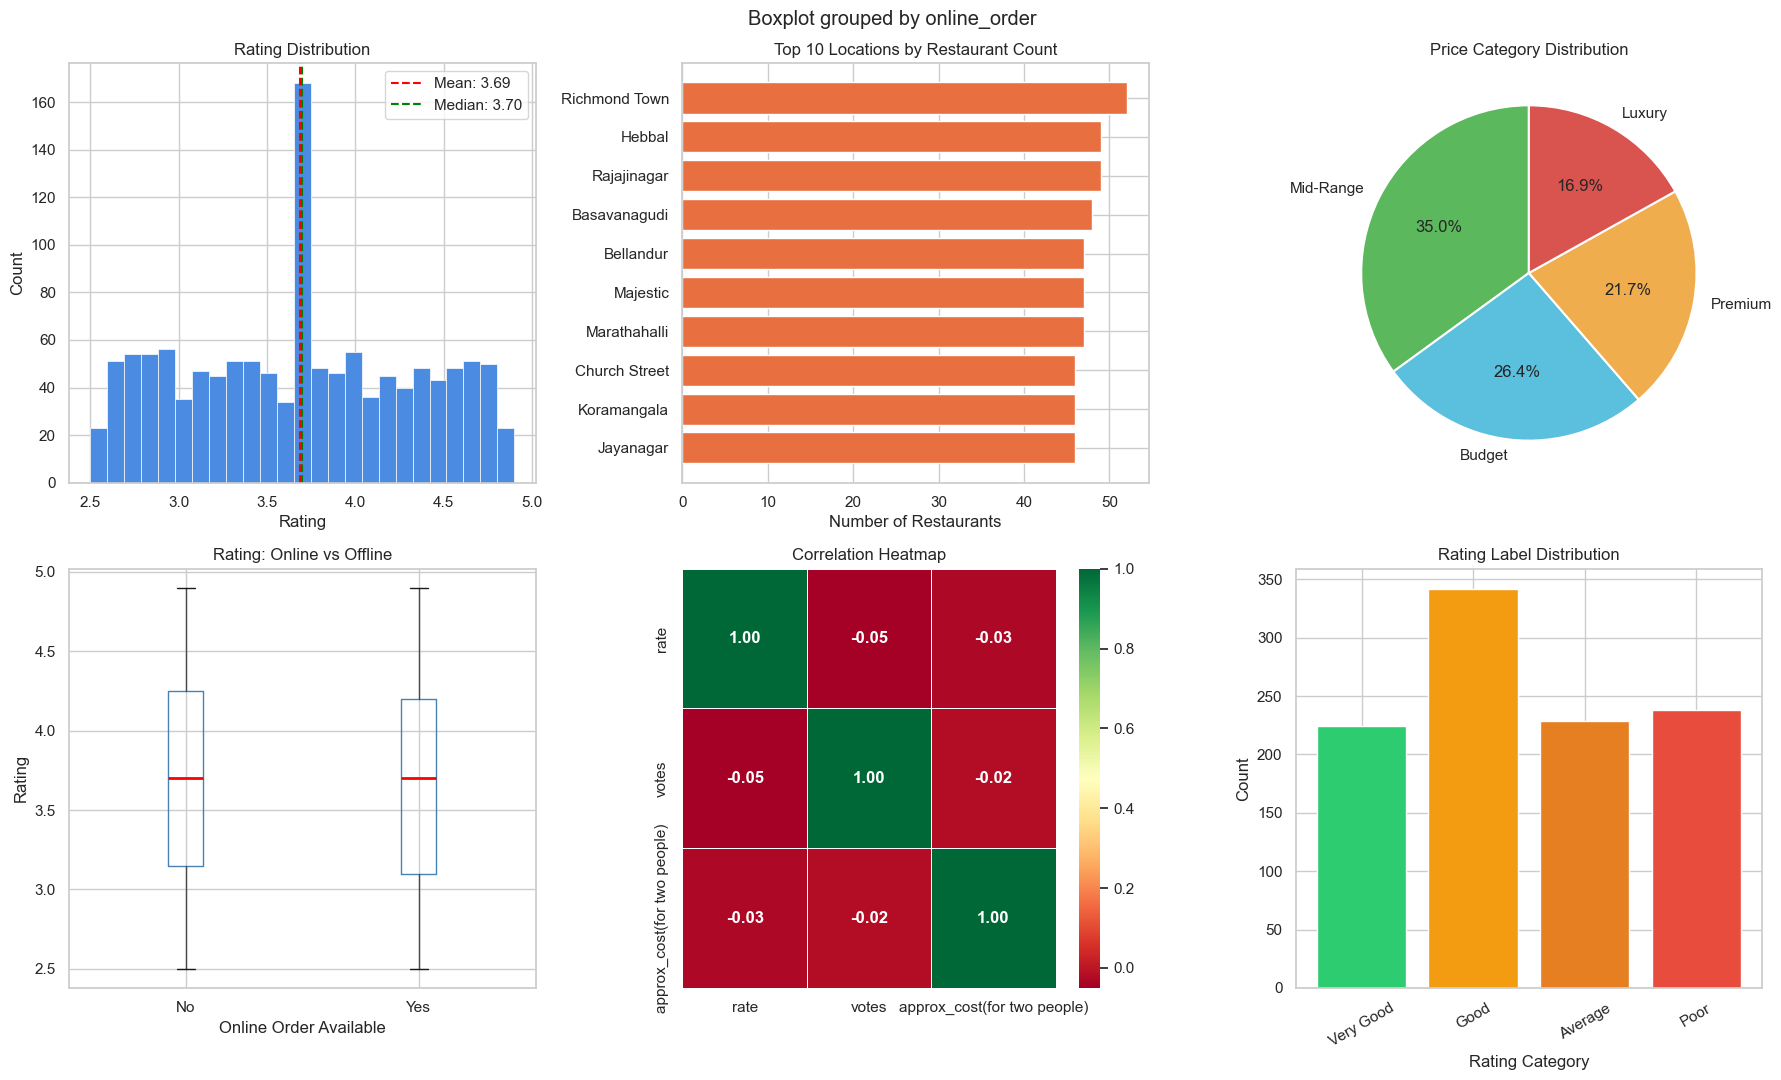

Chart saved → zomato_eda.png ✅


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Zomato Bangalore — Restaurant Analysis',
             fontsize=17, fontweight='bold')

# ── Chart 1 — Rating Distribution ──────────────────────────────

axes[0, 0].hist(df['rate'], bins=25,
                color='#4C8BE2', edgecolor='white', linewidth=0.5)
axes[0, 0].axvline(df['rate'].mean(), 
                   color='red', linestyle='--',
                   label=f"Mean: {df['rate'].mean():.2f}")
axes[0, 0].axvline(df['rate'].median(),
                   color='green', linestyle='--',
                   label=f"Median: {df['rate'].median():.2f}")
axes[0, 0].set_title('Rating Distribution')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()

# ── Chart 2 — Top 10 Locations ─────────────────────────────────
top_locs = df['location'].value_counts().head(10).sort_values()
axes[0, 1].barh(top_locs.index, top_locs.values, color='#E87040')
axes[0, 1].set_title('Top 10 Locations by Restaurant Count')
axes[0, 1].set_xlabel('Number of Restaurants')

# ── Chart 3 — Price Category Pie ───────────────────────────────
price_counts = df['price_category'].value_counts()
colors = ['#5cb85c', '#5bc0de', '#f0ad4e', '#d9534f']
axes[0, 2].pie(price_counts.values,
               labels=price_counts.index,
               autopct='%1.1f%%',
               colors=colors,
               startangle=90,
               wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0, 2].set_title('Price Category Distribution')

# ── Chart 4 — Rating by Online Order (Boxplot) ─────────────────
df.boxplot(column='rate', by='online_order', ax=axes[1, 0],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_title('Rating: Online vs Offline')
axes[1, 0].set_xlabel('Online Order Available')
axes[1, 0].set_ylabel('Rating')
plt.sca(axes[1, 0])
plt.title('Rating: Online vs Offline')

# ── Chart 5 — Correlation Heatmap ──────────────────────────────
corr = df[['rate', 'votes',
           'approx_cost(for two people)']].corr().round(2)
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            ax=axes[1, 1],
            linewidths=0.5,
            annot_kws={'size': 12, 'weight': 'bold'})
axes[1, 1].set_title('Correlation Heatmap')

# ── Chart 6 — Rating Label Count (Bar) ─────────────────────────
order  = ['Excellent', 'Very Good', 'Good', 'Average', 'Poor']
colors = ['#27ae60', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
rl = df['rating_label'].value_counts().reindex(order)
axes[1, 2].bar(rl.index, rl.values,
               color=colors, edgecolor='white')
axes[1, 2].set_title('Rating Label Distribution')
axes[1, 2].set_xlabel('Rating Category')
axes[1, 2].set_ylabel('Count')
axes[1, 2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('zomato_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved → zomato_eda.png ✅")